## Lab - EDA Univariate Analysis: Diving into Amazon UK Product Insights

**Objective**: Explore the product listing dynamics on Amazon UK to extract actionable business insights. By understanding the distribution, central tendencies, and relationships of various product attributes, businesses can make more informed decisions on product positioning, pricing strategies, and inventory management.

**Dataset**: This lab utilizes the [Amazon UK product dataset](https://www.kaggle.com/datasets/asaniczka/uk-optimal-product-price-prediction/)
which provides information on product categories, brands, prices, ratings, and more from from Amazon UK. You'll need to download it to start working with it.


### Part 1: Understanding Product Categories

**Business Question**: What are the most popular product categories on Amazon UK, and how do they compare in terms of listing frequency?

1. **Frequency Tables**:
    - Generate a frequency table for the product `category`.
    - Which are the top 5 most listed product categories?

2. **Visualizations**:
    - Display the distribution of products across different categories using a bar chart. *If you face problems understanding the chart, do it for a subset of top categories.*
    - For a subset of top categories, visualize their proportions using a pie chart. Does any category dominate the listings?

In [26]:
import pandas as pd

df = pd.read_csv("amz_uk_price_prediction_dataset.csv")


In [28]:
df['category'].value_counts()

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
                                           ...  
Alexa Built-In Devices                       107
Motorbike Chassis                            107
Plugs                                        107
Smart Home Security & Lighting               104
Smart Speakers                                54
Name: count, Length: 296, dtype: int64

In [32]:
top_5 = df['category'].value_counts().head(5)
top_5

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
Name: count, dtype: int64

<Axes: xlabel='category'>

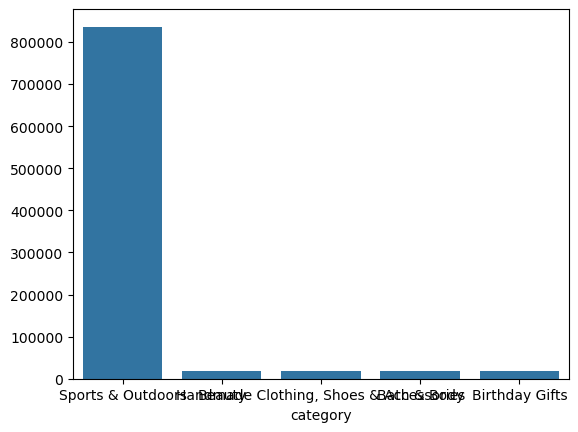

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x=top_5.index, y=top_5.values)


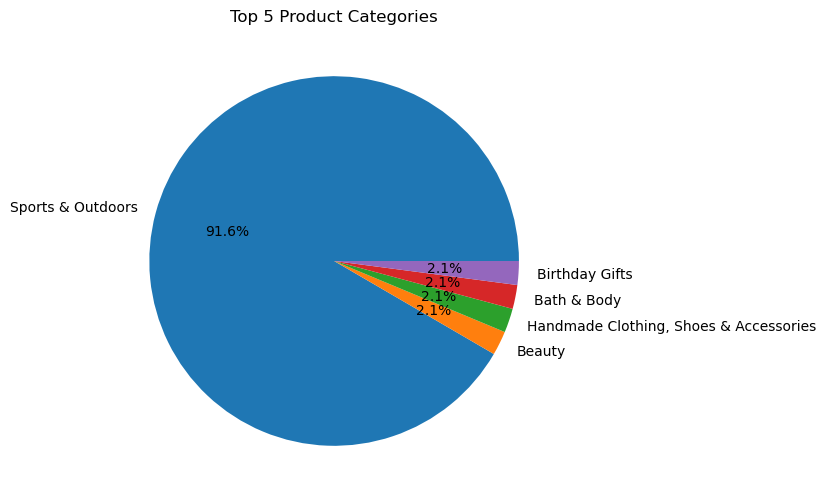

In [42]:
top_5.plot.pie(autopct='%1.1f%%', figsize=(6, 6), ylabel='')
plt.title("Top 5 Product Categories")
plt.show()

### Part 2: Delving into Product Pricing

**Business Question**: How are products priced on Amazon UK, and are there specific price points or ranges that are more common?

1. **Measures of Centrality**:
    - Calculate the mean, median, and mode for the `price` of products.
    - What's the average price point of products listed? How does this compare with the most common price point (mode)?

2. **Measures of Dispersion**:
    - Determine the variance, standard deviation, range, and interquartile range for product `price`.
    - How varied are the product prices? Are there any indicators of a significant spread in prices?

3. **Visualizations**:
    - Is there a specific price range where most products fall? Plot a histogram to visualize the distribution of product prices. *If its hard to read these diagrams, think why this is, and explain how it could be solved.*.
    - Are there products that are priced significantly higher than the rest? Use a box plot to showcase the spread and potential outliers in product pricing. 


In [46]:
mean_price = df['price'].mean()
median_price = df['price'].median()
mode_price = df['price'].mode()[0]

print("Mean:", mean_price)
print("Median:", median_price)
print("Mode:", mode_price)

Mean: 89.24380943923663
Median: 19.09
Mode: 9.99


In [48]:
variance = df['price'].var()
std_dev = df['price'].std()
price_range = df['price'].max() - df['price'].min()
q1 = df['price'].quantile(0.25)
q3 = df['price'].quantile(0.75)
iqr = q3 - q1

print("Variance:", variance)
print("Standard Deviation:", std_dev)
print("Range:", price_range)
print("Interquartile Range (IQR):", iqr)


Variance: 119445.48532256528
Standard Deviation: 345.60886175352226
Range: 100000.0
Interquartile Range (IQR): 36.0


Prices are really spread. between minimum and maximum price is large. std and variance are also high, so prices are not near the mean.

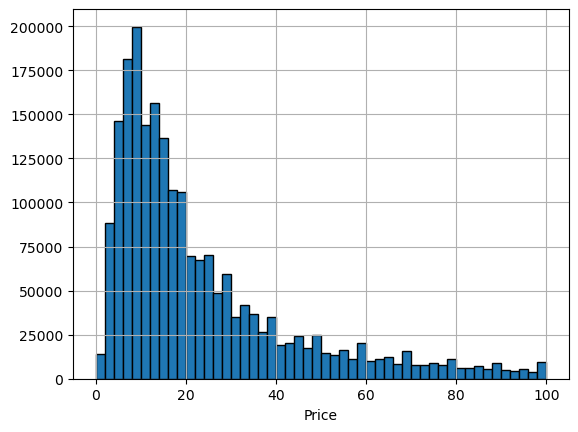

In [62]:
df[df['price'] < 100]['price'].hist(bins=50, edgecolor='black')
plt.xlabel('Price')
plt.grid(True)

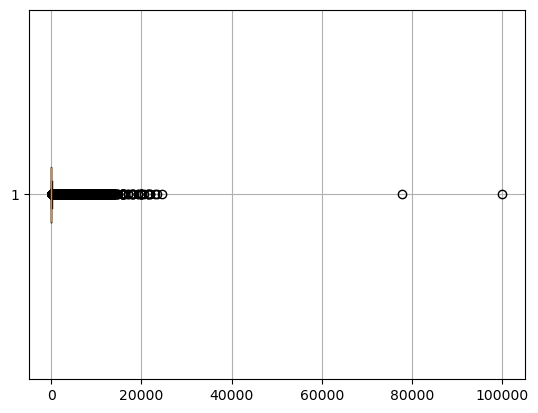

In [80]:
plt.boxplot(df['price'], vert=False)
plt.grid(True)
plt.show()

Hard to interpret.

### Part 3: Unpacking Product Ratings

**Business Question**: How do customers rate products on Amazon UK, and are there any patterns or tendencies in the ratings?

1. **Measures of Centrality**:
    - Calculate the mean, median, and mode for the `rating` of products.
    - How do customers generally rate products? Is there a common trend?

2. **Measures of Dispersion**:
    - Determine the variance, standard deviation, and interquartile range for product `rating`.
    - Are the ratings consistent, or is there a wide variation in customer feedback?

3. **Shape of the Distribution**:
    - Calculate the skewness and kurtosis for the `rating` column. 
    - Are the ratings normally distributed, or do they lean towards higher or lower values?

4. **Visualizations**:
    - Plot a histogram to visualize the distribution of product ratings. Is there a specific rating that is more common?

In [84]:
df.columns


Index(['uid', 'asin', 'title', 'stars', 'reviews', 'price', 'isBestSeller',
       'boughtInLastMonth', 'category'],
      dtype='object')

In [100]:
df_rated = df[df['stars'] > 0]

mean_rating = df_rated['stars'].mean()
median_rating = df_rated['stars'].median()
mode_rating = df_rated['stars'].mode()[0]

print("Mean:", mean_rating)
print("Median:", median_rating)
print("Mode:", mode_rating)

Mean: 4.31916076222691
Median: 4.4
Mode: 4.5


In [ ]:
Customers generally rate 4 or 5

In [92]:
df['stars'].value_counts(dropna=False)


stars
0.0    1225641
4.5     151577
4.6     136995
4.4     136165
5.0     128492
4.3     112564
4.7      94566
4.2      86871
4.0      66089
4.1      65115
4.8      41858
3.9      36555
3.8      27876
3.7      21137
3.6      16219
3.5      14673
3.0      12819
4.9      11081
3.4      10355
1.0       8484
3.3       8269
3.2       5771
3.1       4679
2.0       3901
2.9       3341
2.8       2306
2.7       2104
2.5       2103
2.6       1579
2.4       1060
2.3        734
2.2        602
2.1        540
1.5        404
1.9        300
1.8        249
1.7        177
1.4        149
1.6        147
1.3         78
1.2         23
1.1          3
Name: count, dtype: int64

In [102]:
variance_rating = df_rated['stars'].var()

std_rating = df_rated['stars'].std()

q1 = df_rated['stars'].quantile(0.25)
q3 = df_rated['stars'].quantile(0.75)
iqr_rating = q3 - q1

print("Variance:", variance_rating)
print("Standard Deviation:", std_rating)
print("Interquartile Range (IQR):", iqr_rating)

Variance: 0.3083433752380519
Standard Deviation: 0.5552867504614637
Interquartile Range (IQR): 0.5


"Prices are very spread out. The range is large, and both standard deviation and variance are high. 

This means prices vary a lot and are not close to the average."


In [104]:
skew = df_rated['stars'].skew()
kurt = df_rated['stars'].kurt()

In [106]:
print("Skewness:", skew)
print("Kurtosis:", kurt)

Skewness: -2.3795681122127945
Kurtosis: 9.78193769066435


Ratings have negative skewness (-2.38), meaning most are high. 

Kurtosis is high (9.78), so ratings are very concentrated around 4–5 stars. 

This means customers mostly give very positive feedback.

C:\Users\PcVIP\AppData\Local\Temp\ipykernel_21872\3192495369.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rating_counts.index, y=rating_counts.values, palette='Blues_d')


<Axes: xlabel='stars'>

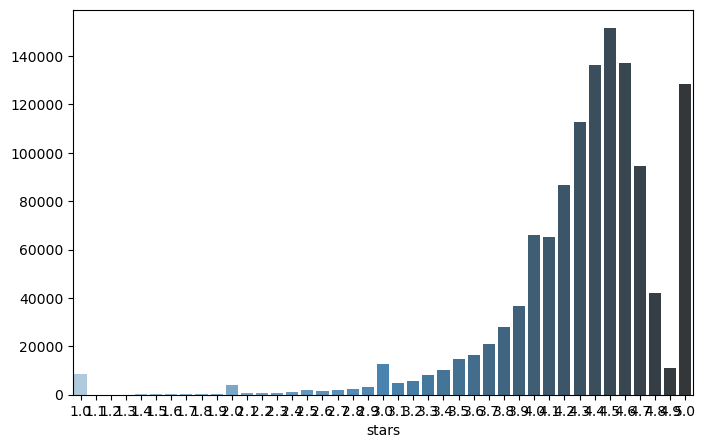

In [108]:
rating_counts = df_rated['stars'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
sns.barplot(x=rating_counts.index, y=rating_counts.values, palette='Blues_d')

The barplot shows that most products have high ratings (between 4 and 5 stars). 

This matches the negative skewness and high kurtosis, confirming that customer feedback is very positive overall.